<a href="https://colab.research.google.com/github/GenerationBR/Projeto-People-Analytics/blob/main/Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tratamento - State of Data 2021  - Data Hacker

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.graph_objects as go
from plotly.subplots import make_subplots
df = pd.read_csv ('/content/State of Data 2021 - Dataset - Pgina1.csv', low_memory=False)
# Organização e limpaza dos dados
df.columns = df.columns.str.replace(r"[()'\"]", "", regex=True)
df.columns = df.columns.str.replace(r"\s*,\s*", ", ", regex=True).str.strip()
mapeamento_colunas = {
    "P0, id": "ID",
    "P1_a, Idade": "idade",
    "P1_a_a, Faixa idade": "faixa_idade",
    "P1_b, Genero": "genero",
    "P1_e, Estado onde mora": "estado",
    "P1_e_b, Regiao onde mora": "regiao",
    "P1_h, Nivel de Ensino": "escolaridade",
    "P1_i, Área de Formação": "curso",
    "P2_a, Qual sua situação atual de trabalho?": "tipo_trabalho",
    "P2_d, Gestor?":"é gestor?",
    "P2_e, Cargo como Gestor": "Cargo de Gestão",
    "P2_f, Cargo Atual": "cargo",
    "P2_g, Nivel": "senioridade",
    "P2_h, Faixa salarial": "faixa salarial",
    "P2_i, Quanto tempo de experiência na área de dados você tem?": "tempo de experiencia"
}
df_limpo = df[list(mapeamento_colunas.keys())].copy()
df_limpo = df_limpo.rename(columns=mapeamento_colunas)
print("Colunas criadas com sucesso:")
print(df_limpo.columns.tolist())
df_limpo = df_limpo.dropna(subset=['genero', 'faixa salarial'])
# Métrica A: Criar coluna binária de Liderança (Sim/Não) baseado nos cargos do formulário
cargos_lidereranca = ['Gestor', 'Coordenador', 'Diretor', 'Gerente', 'Head', 'Lead', 'Chief']
df_limpo['é gestor?'] = df_limpo['é gestor?'].map({1: 'Sim', 0: 'Não'})
print(df.isnull().sum())
# Métrica B: Converter as faixas salariais de texto para valores numéricos aproximados
mapeamento_valores_salario = {
    'Menos de R$ 1.000/mês': 800,
    'de R$ 1.001/mês a R$ 2.000/mês': 1500,
    'de R$ 2.001/mês a R$ 4.000/mês': 3000,
    'de R$ 4.001/mês a R$ 6.000/mês': 5000,
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000,
    'Acima de R$ 40.000/mês': 45000
}
df_limpo['salario_numerico'] = df_limpo['faixa salarial'].map(mapeamento_valores_salario)
# Verificação se houve erro no mapeamento (colunas que ficaram NaN)
if df_limpo['salario_numerico'].isnull().any():
    print("Aviso: Algumas faixas salariais não foram mapeadas corretamente. Verificando valores únicos...")
    print(df_limpo[df_limpo['salario_numerico'].isnull()]['faixa salarial'].unique())
# Agregação para o Dashboard
df_agregado = df_limpo.groupby(['genero', 'senioridade', 'cargo']).agg({
    'salario_numerico': 'mean',
    'ID': 'count'
}).rename(columns={'ID': 'quantidade'}).reset_index()
# EXPORTAÇÃO
df_limpo.to_csv('/content/StateOfData_2021_Tratado.csv', index=False)
df_agregado.to_csv('/content/StateOfData_2021_Agregado.csv', index=False)

print("\n--- Processamento Sênior Concluído ---")
print(f"Arquivo completo exportado: 'StateOfData_2021_Tratado.csv' ({len(df_limpo)} linhas)")
print(f"Arquivo agregado para Dashboard: 'StateOfData_2021_Agregado.csv'")
print(f"Média Salarial Mulheres: R$ {df_limpo[df_limpo['genero']=='Feminino']['salario_numerico'].mean():.2f}")
print(f"Média Salarial Homens: R$ {df_limpo[df_limpo['genero']=='Masculino']['salario_numerico'].mean():.2f}")

Colunas criadas com sucesso:
['ID', 'idade', 'faixa_idade', 'genero', 'estado', 'regiao', 'escolaridade', 'curso', 'tipo_trabalho', 'é gestor?', 'Cargo de Gestão', 'cargo', 'senioridade', 'faixa salarial', 'tempo de experiencia']
P0, id                                        0
P1_a, Idade                                  28
P1_a_a, Faixa idade                           0
P1_b, Genero                                  0
P1_e, Estado onde mora                       36
                                             ..
P9_a_b, Podcast do Data Hackers               0
P9_a_d, Newsletter Semanal                    0
P9_a_e, Canal do Slack                        0
P9_a_f, Canal do Youtube do Data Hackers      0
P9_a_g, Ainda não conhecia o Data Hackers     0
Length: 356, dtype: int64
Aviso: Algumas faixas salariais não foram mapeadas corretamente. Verificando valores únicos...
['de R$ 3.001/mês a R$ 4.000/mês' 'Acima de R$ 40.001/mês'
 'de R$ 2.001/mês a R$ 3000/mês']

--- Processamento Sênior Co

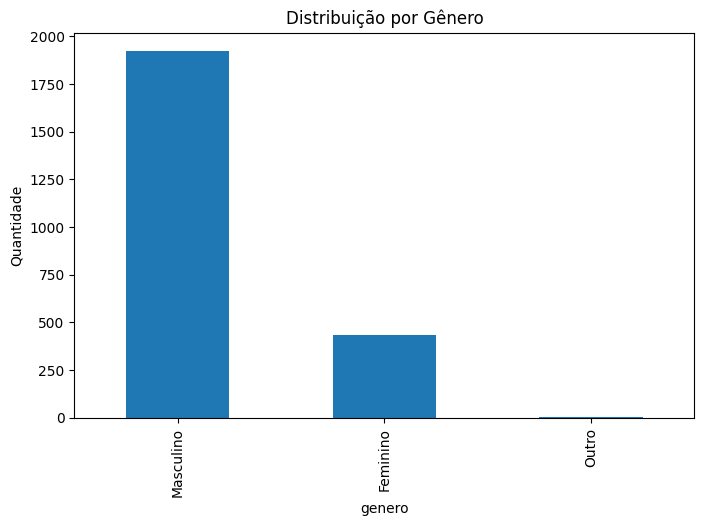

In [3]:
genero = df_limpo['genero'].value_counts()

plt.figure(figsize=(8,5))
genero.plot(kind='bar')
plt.title('Distribuição por Gênero')
plt.ylabel('Quantidade')
plt.show()

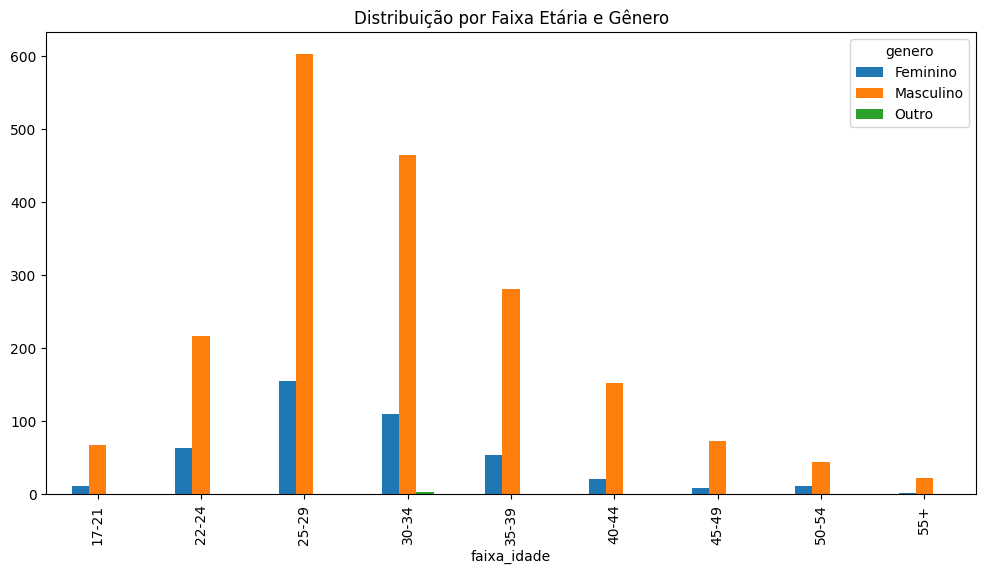

In [4]:
idade_genero = pd.crosstab(
    df_limpo['faixa_idade'],
    df_limpo['genero']
)

idade_genero.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Distribuição por Faixa Etária e Gênero')
plt.show()

<Axes: xlabel='escolaridade'>

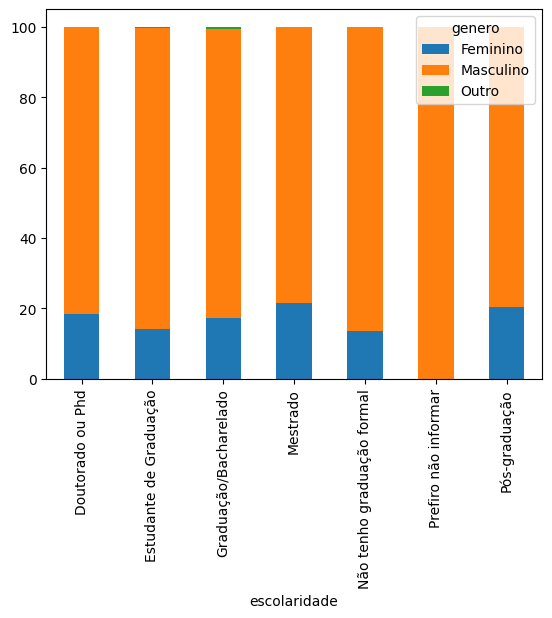

In [5]:
esc = pd.crosstab(
    df_limpo['escolaridade'],
    df_limpo['genero'],
    normalize='index'
) * 100

esc.plot(kind='bar', stacked=True)

# Web Scraping Linkedin

In [6]:
#  Instalar Bibliotecas
!apt update
!apt install chromium-chromedriver -y

!pip install selenium pandas webdriver-manager

# Configurar o Selenium (uma espécie de BeautifulSoup, mais elaborado)
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys

import pandas as pd
import time

options = Options()

options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--disable-gpu")

driver = webdriver.Chrome(options=options)

# Pesquisar Vagas
cargo = "Data Analyst"

url = f"https://www.linkedin.com/jobs/search/?keywords={cargo.replace(' ','%20')}&location=Brasil"

driver.get(url)

time.sleep(5)

# Coletar links das vagas
links = []

cards = driver.find_elements(By.CSS_SELECTOR,"a.base-card__full-link")

for c in cards:
    links.append(c.get_attribute("href"))

print(len(links))

# Visitar vagas
dados = []

for link in links[:30]:

    driver.get(link)

    time.sleep(3)

    try:
        titulo = driver.find_element(By.TAG_NAME,"h1").text
    except:
        titulo = ""

    try:
        empresa = driver.find_element(By.CLASS_NAME,"topcard__org-name-link").text
    except:
        empresa = ""

    try:
        descricao = driver.find_element(By.CLASS_NAME,"show-more-less-html__markup").text
    except:
        descricao = ""

    dados.append({
        "empresa":empresa,
        "titulo":titulo,
        "descricao":descricao
    })

# Listar palavras afirmativas
palavras = [

"mulheres",

"women",

"diversidade",

"inclusão",

"inclusiva",

"vaga afirmativa",

"affirmative",

"equidade",

"igualdade",

"diverse",

"female",

"gender equality",

"inclusion",

"minorias",

"grupos sub-representados",

"pcd",

"lgbt",

"lgbtq",

"negros",

"racial"

]

# Classificador
def vaga_afirmativa(texto):

    texto = texto.lower()

    for palavra in palavras:

        if palavra.lower() in texto:

            return True

    return False

# Aplicar classificação
df = pd.DataFrame(dados)

df["afirmativa"] = df["descricao"].apply(vaga_afirmativa)

df.head()

# Estatísticas
total = len(df)

afirmativas = df["afirmativa"].sum()

nao = total - afirmativas

print(f"Total de vagas: {total}")

print(f"Afirmativas: {afirmativas}")

print(f"Não afirmativas: {nao}")

print(f"Percentual: {100*afirmativas/total:.2f}%")

# Salvar CSV
df.to_csv("linkedin_vagas.csv",index=False)

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,221 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,361 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Package

SessionNotCreatedException: Message: session not created: Chrome instance exited. Examine ChromeDriver verbose log to determine the cause.; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#sessionnotcreatedexception
Stacktrace:
#0 0x55c68dba566a <unknown>
#1 0x55c68d57db19 <unknown>
#2 0x55c68d5bc447 <unknown>
#3 0x55c68d5b7dde <unknown>
#4 0x55c68d60770e <unknown>
#5 0x55c68d606dfc <unknown>
#6 0x55c68d5c665f <unknown>
#7 0x55c68d5c74c1 <unknown>
#8 0x55c68db6a9b7 <unknown>
#9 0x55c68db69188 <unknown>
#10 0x55c68db53e66 <unknown>
#11 0x55c68db69d5a <unknown>
#12 0x55c68db3bda0 <unknown>
#13 0x55c68db90e28 <unknown>
#14 0x55c68db90fc5 <unknown>
#15 0x55c68dba421e <unknown>
#16 0x7b992c9a8ac3 <unknown>


# Teste T

In [7]:
# TESTE T - DIFERENÇA SALARIAL POR GÊNERO

import pandas as pd
from scipy.stats import ttest_ind

# Carregar a base de dados
df = pd.read_csv("/content/base_mercado_tech_brasil (1).csv")

# Separar os grupos
salario_homens = df[df["genero"] == "Masculino"]["salario_brl"]
salario_mulheres = df[df["genero"] == "Feminino"]["salario_brl"]

# Estatísticas descritivas
print("===== Estatísticas =====\n")

print(f"Quantidade de homens: {len(salario_homens)}")
print(f"Quantidade de mulheres: {len(salario_mulheres)}\n")

print(f"Média salarial dos homens: R$ {salario_homens.mean():,.2f}")
print(f"Média salarial das mulheres: R$ {salario_mulheres.mean():,.2f}\n")

print(f"Desvio padrão homens: R$ {salario_homens.std():,.2f}")
print(f"Desvio padrão mulheres: R$ {salario_mulheres.std():,.2f}")

# Teste T de Welch
t_stat, p_valor = ttest_ind(
    salario_homens,
    salario_mulheres,
    equal_var=False,
    nan_policy="omit"
)

print("\n===== Teste T =====")
print(f"Estatística T = {t_stat:.4f}")
print(f"P-valor = {p_valor:.40f}")

# Interpretação
alpha = 0.05

print("\n===== Conclusão =====")

if p_valor < alpha:
    print("Rejeita-se H0.")
    print("Existe diferença estatisticamente significativa entre os salários médios de homens e mulheres.")
else:
    print("Não se rejeita H0.")
    print("Não foi encontrada diferença estatisticamente significativa entre os grupos.")

===== Estatísticas =====

Quantidade de homens: 610
Quantidade de mulheres: 390

Média salarial dos homens: R$ 4,474.73
Média salarial das mulheres: R$ 3,149.05

Desvio padrão homens: R$ 2,015.51
Desvio padrão mulheres: R$ 1,305.52

===== Teste T =====
Estatística T = 12.6228
P-valor = 0.0000000000000000000000000000000005377450

===== Conclusão =====
Rejeita-se H0.
Existe diferença estatisticamente significativa entre os salários médios de homens e mulheres.
